In [1]:
# load and plot dataset
from pandas import read_excel
from pandas import read_csv
from pandas import datetime
import pandas as pd
from matplotlib import pyplot


# load dataset
series = read_csv('time_series_60min_singleindex_16.csv', squeeze=True)

series.head()

series['utc_timestamp'] = pd.to_datetime(series['utc_timestamp'])

/Users/ahmadyani/opt/anaconda3/lib/python3.7/site-packages/pandas/core/arrays/datetimes.py:1269: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  UserWarning,


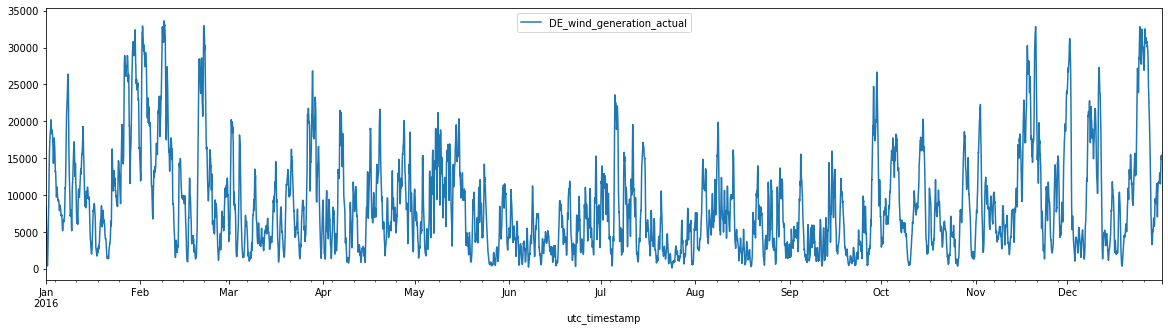

In [2]:
# line plot
series.plot('utc_timestamp', 'DE_wind_generation_actual', figsize=(20,5))
pyplot.show()

In [3]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from math import sqrt
from matplotlib import pyplot
from sklearn.preprocessing import MinMaxScaler
import numpy
from pandas import Series
from pandas import DataFrame
from pandas import concat
from keras.optimizers import Adam
from keras.layers import Dropout

# create a differenced series
def difference(dataset, interval=1):
	diff = list()
	for i in range(interval, len(dataset)):
		value = dataset[i] - dataset[i - interval]
		diff.append(value)
	return Series(diff)

# transform data to be stationary
raw_values = series['DE_wind_generation_actual'].values
diff_values = difference(raw_values, 1)
print(diff_values)

# frame a sequence as a supervised learning problem
def timeseries_to_supervised(data, lag=1):
	df = DataFrame(data)
	columns = [df.shift(i) for i in range(1, lag+1)]
	columns.append(df)
	df = concat(columns, axis=1)
	df.fillna(0, inplace=True)
	return df

# transform data to be supervised learning
supervised = timeseries_to_supervised(diff_values, 1)
supervised_values = supervised.values
# diff_values.dropna(axis=0, inplace=True)
supervised_values

# split data into train and test-sets
train, test = supervised_values[0:-109], supervised_values[-109:]

# scale train and test data to [-1, 1]
def scale(train, test):
	# fit scaler
	scaler = MinMaxScaler(feature_range=(-1, 1))
	scaler = scaler.fit(train)
	# transform train
	train = train.reshape(train.shape[0], train.shape[1])
	train_scaled = scaler.transform(train)
	# transform test
	test = test.reshape(test.shape[0], test.shape[1])
	test_scaled = scaler.transform(test)
	return scaler, train_scaled, test_scaled

# transform the scale of the data
scaler, train_scaled, test_scaled = scale(train, test)

# fit an LSTM network to training data
def fit_lstm(train, batch_size, nb_epoch, neurons):
	X, y = train[:, 0:-1], train[:, -1]
	X = X.reshape(X.shape[0], 1, X.shape[1])
	model = Sequential()
	model.add(LSTM(neurons, batch_input_shape=(batch_size, X.shape[1], X.shape[2]), stateful=True))
	model.add(Dropout(0.2))
	model.add(Dense(1))
	model.compile(loss='mean_squared_error', optimizer='adam')
	for i in range(nb_epoch):
		model.fit(X, y, epochs=1, batch_size=batch_size, validation_data=(X, y), shuffle=False)
		model.reset_states()
	return model

# fit the model
lstm_model = fit_lstm(train_scaled, 1, 50, 50)
lstm_model.summary()
# lstm_model.save_weights('model.h5')
# forecast the entire training dataset to build up state for forecasting
train_reshaped = train_scaled[:, 0].reshape(len(train_scaled), 1, 1)
lstm_model.predict(train_reshaped, batch_size=1)

# make a one-step forecast
def forecast_lstm(model, batch_size, X):
	X = X.reshape(1, 1, len(X))
	yhat = model.predict(X, batch_size=batch_size)
	return yhat[0,0]

# inverse scaling for a forecasted value
def invert_scale(scaler, X, value):
	new_row = [x for x in X] + [value]
	array = numpy.array(new_row)
	array = array.reshape(1, len(array))
	inverted = scaler.inverse_transform(array)
	return inverted[0, -1]

# invert differenced value
def inverse_difference(history, yhat, interval=1):
	return yhat + history[-interval]

# walk-forward validation on the test data
predictions = list()
for i in range(len(test_scaled)):
	# make one-step forecast
	X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
	yhat = forecast_lstm(lstm_model, 1, X)
	# invert scaling
	yhat = invert_scale(scaler, X, yhat)
	# invert differencing
	yhat = inverse_difference(raw_values, yhat, len(test_scaled)+1-i)
	# store forecast
	predictions.append(yhat)
	expected = raw_values[len(train) + i + 1]
	print('Hour=%d, Predicted=%f, Expected=%f' % (i+1, yhat, expected))

Using TensorFlow backend.


0       -37
1       -99
2      -148
3      -976
4      -745
       ... 
8778    107
8779     51
8780   -506
8781    208
8782    366
Length: 8783, dtype: int64
Train on 8674 samples, validate on 8674 samples
Epoch 1/1
8674/8674 [==============================] - 13s 2ms/step - loss: 0.0135 - val_loss: 0.0120
Train on 8674 samples, validate on 8674 samples
Epoch 1/1
8674/8674 [==============================] - 13s 1ms/step - loss: 0.0126 - val_loss: 0.0121
Train on 8674 samples, validate on 8674 samples
Epoch 1/1
8674/8674 [==============================] - 12s 1ms/step - loss: 0.0124 - val_loss: 0.0120
Train on 8674 samples, validate on 8674 samples
Epoch 1/1
8674/8674 [==============================] - 13s 1ms/step - loss: 0.0123 - val_loss: 0.0120
Train on 8674 samples, validate on 8674 samples
Epoch 1/1
8674/8674 [==============================] - 12s 1ms/step - loss: 0.0122 - val_loss: 0.0119
Train on 8674 samples, validate on 8674 samples
Epoch 1/1
8674/8674 [======================

Hour=1, Predicted=29397.258058, Expected=28862.000000
Hour=2, Predicted=28320.205175, Expected=28293.000000
Hour=3, Predicted=27921.161953, Expected=26973.000000
Hour=4, Predicted=25842.977737, Expected=25522.000000
Hour=5, Predicted=24476.885532, Expected=24645.000000
Hour=6, Predicted=24304.063639, Expected=24266.000000
Hour=7, Predicted=24112.535575, Expected=23514.000000
Hour=8, Predicted=22849.044555, Expected=23032.000000
Hour=9, Predicted=22795.625108, Expected=22002.000000
Hour=10, Predicted=21115.965020, Expected=20840.000000
Hour=11, Predicted=19975.096159, Expected=20409.000000
Hour=12, Predicted=20405.075716, Expected=20225.000000
Hour=13, Predicted=20114.125974, Expected=19681.000000
Hour=14, Predicted=19197.105878, Expected=19099.000000
Hour=15, Predicted=18706.168054, Expected=18198.000000
Hour=16, Predicted=17465.387671, Expected=17324.000000
Hour=17, Predicted=16704.811222, Expected=16279.000000
Hour=18, Predicted=15473.294669, Expected=15285.000000
Hour=19, Predicted=

Test RMSE:  381.318697


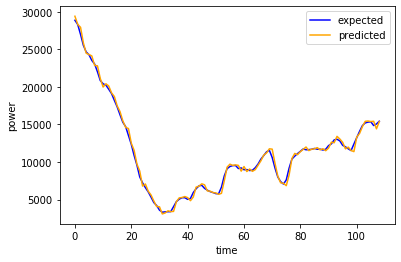

In [4]:
from sklearn.metrics import mean_squared_error
# raw_values[-1] = raw_values[-12:].mean()

# report performance
rmse = sqrt(mean_squared_error(raw_values[-109:], predictions))
print('Test RMSE: % f' % rmse)
# line plot of observed vs predicted
pyplot.plot(raw_values[-109:],color='blue', label = 'expected')
pyplot.plot(predictions,color='orange', label = 'predicted')
pyplot.xlabel("time")
pyplot.ylabel("power")
pyplot.legend()
pyplot.show()